# Лабораторная работа №2
## Исследовательский анализ данных (EDA) 

**Тема:** Анализ факторов популярности музыкальных треков Spotify

---

## 1. Анализ распределения признаков

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv('dataset.csv') 

print("Датасет для EDA успешно загружен")
df.head()

Датасет для EDA успешно загружен


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


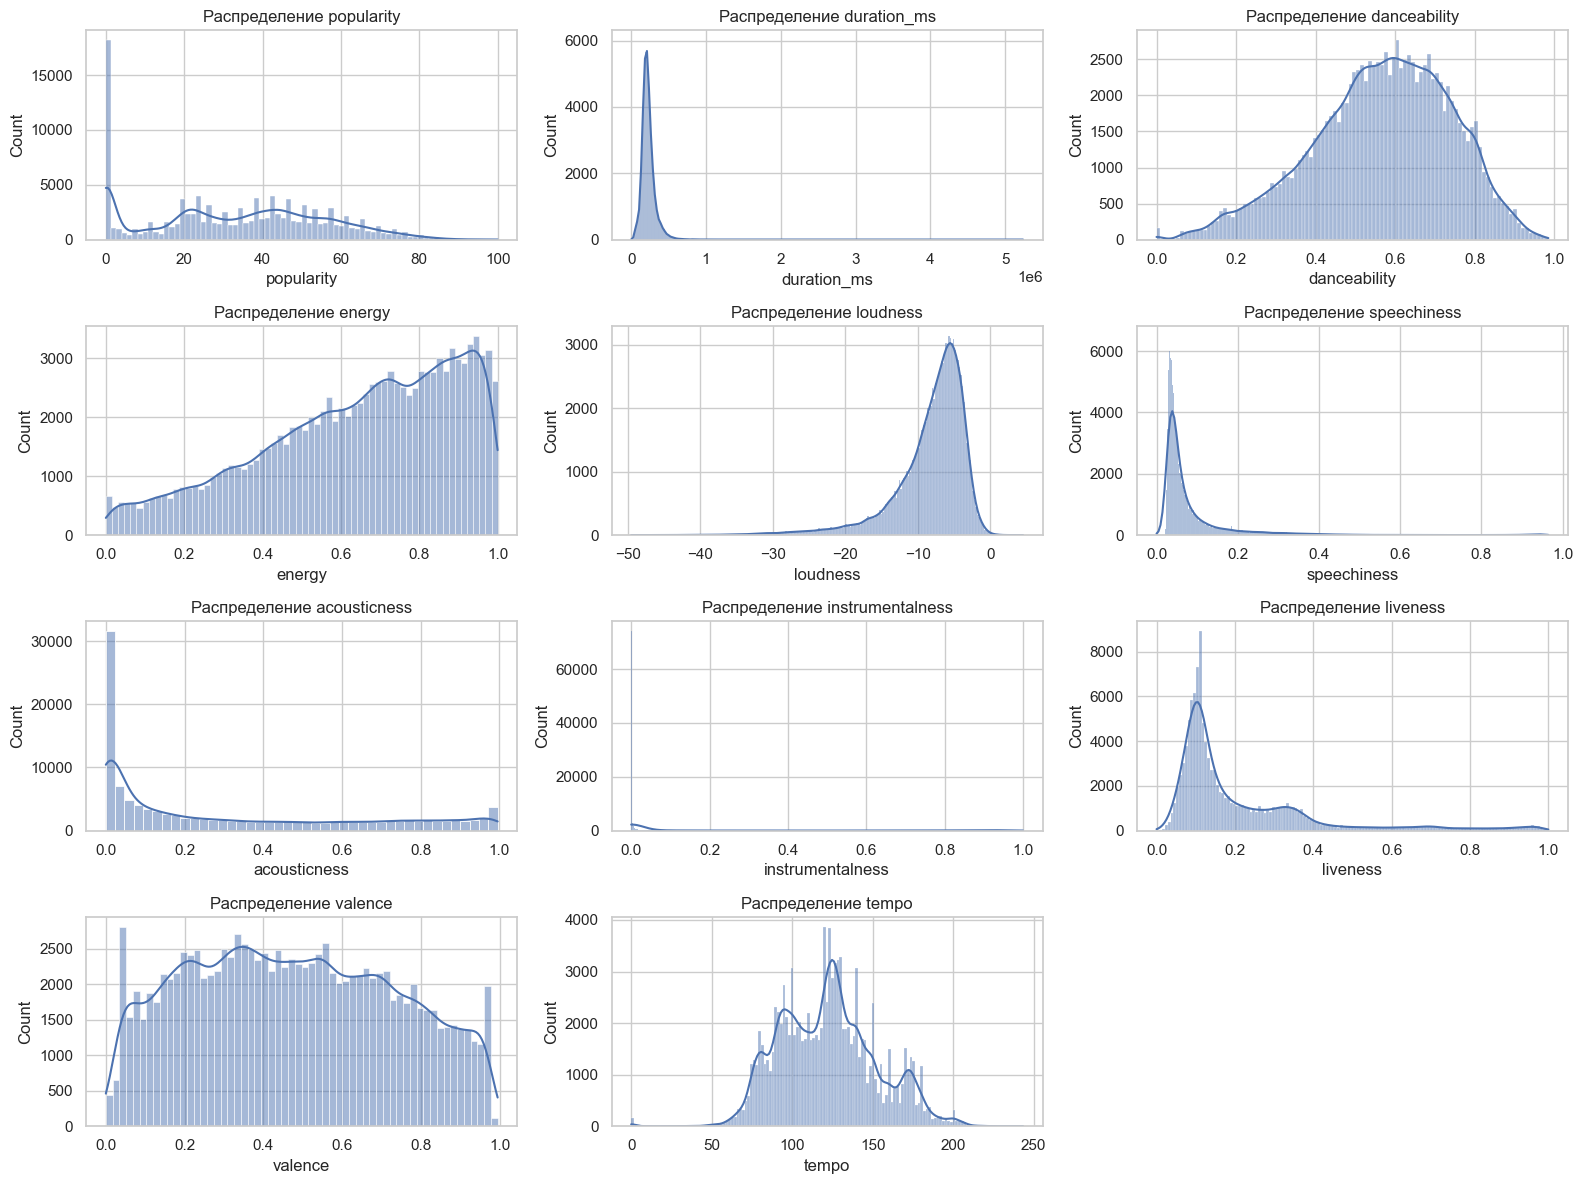

In [3]:
# Список числовых колонок для анализа
numerical_cols = [
    'popularity', 'duration_ms', 'danceability', 'energy', 
    'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
    'liveness', 'valence', 'tempo'
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    
    # Строим гистограмму и график плотности (kde=True)
    sns.histplot(df[col], kde=True)
    
    plt.title(f'Распределение {col}')

plt.tight_layout()
plt.show()

## Анализ распределения признаков
* popularity: Скошено вправо. Большинство треков имеют среднюю или низкую популярность, и есть длинный хвост из очень непопулярных треков включая те, у которых популярность 0.
* duration_ms: Скошено вправо. Большинство песен имеют стандартную длительность, но есть очень длинные треки выбросы, которые создают длинный хвост.
* danceability, energy, valence: Похожи на нормальное распределение, но немного смещены. 
* loudness: Скошено влево. Большинство треков имеют громкость близкую к максимальной, и есть хвост из тихих треков.
* acousticness, instrumentalness, speechiness, liveness: Скошены вправо. Подавляющее большинство треков не являются акустическими или инструментальными, поэтому мы видим огромный пик около нуля.

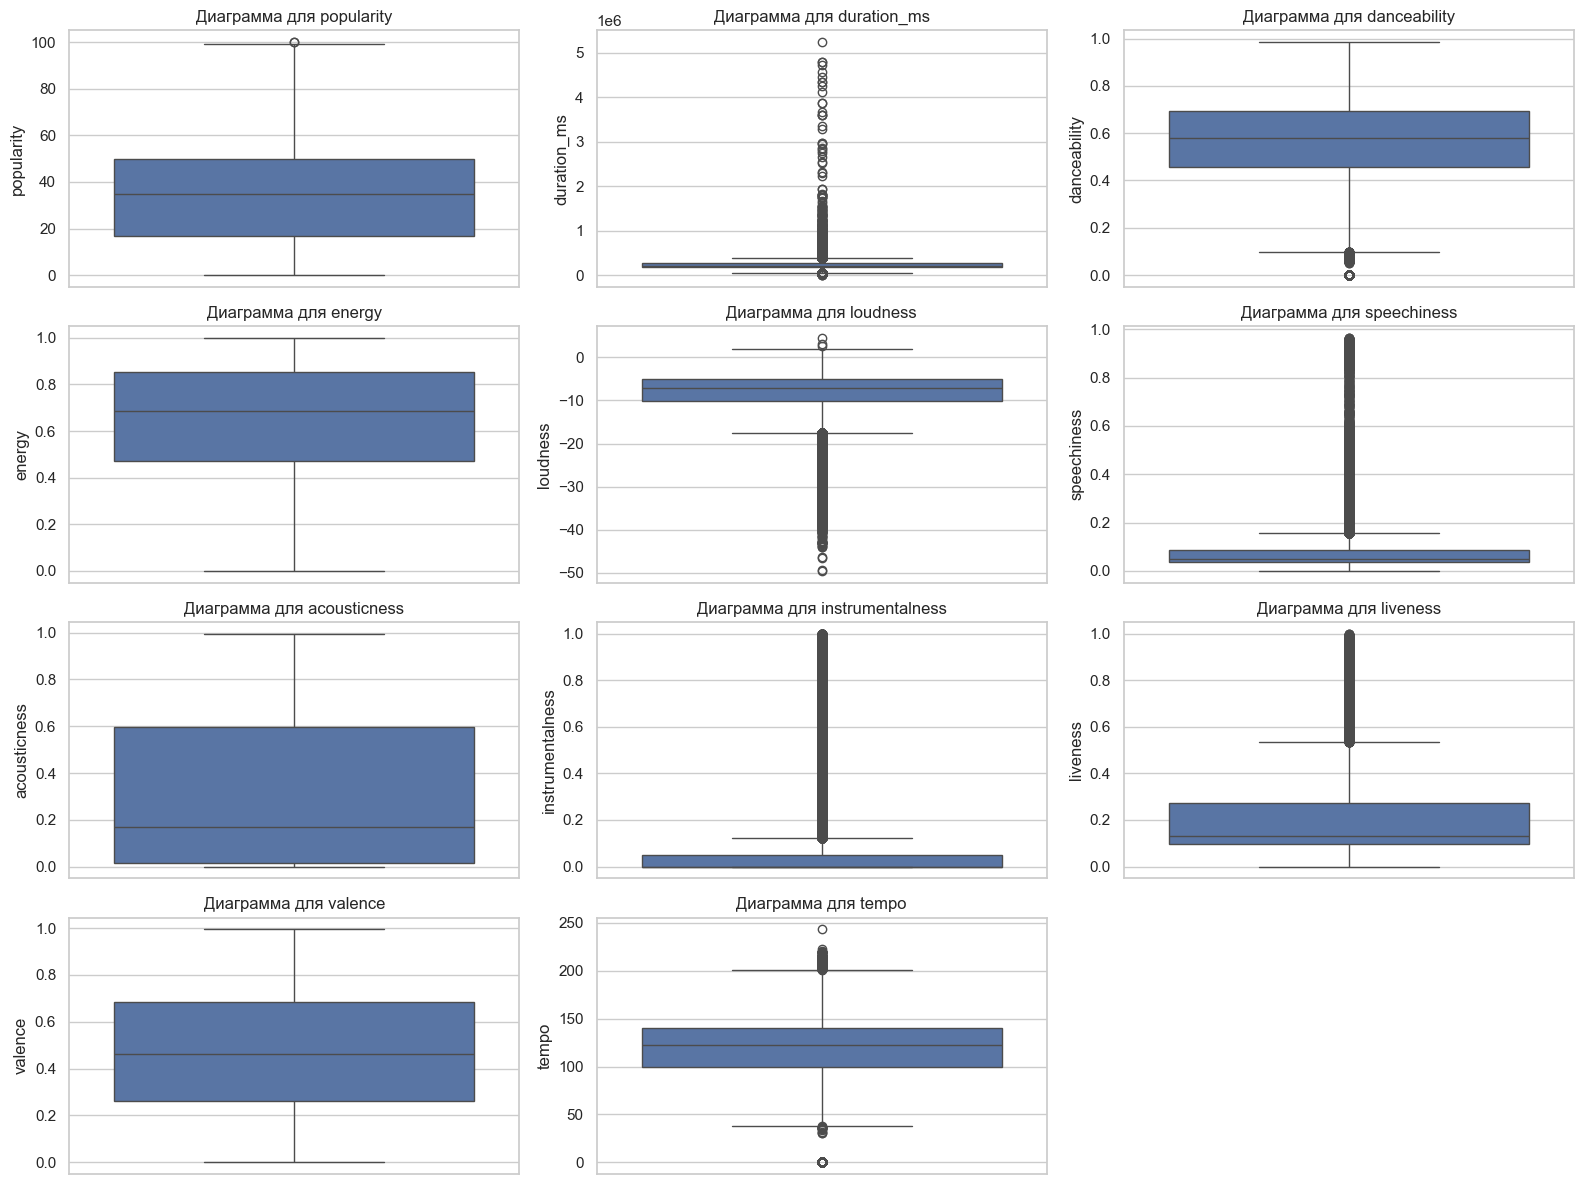

In [4]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    
    # Строим boxplot
    sns.boxplot(y=df[col]) # y=... делает ящик вертикальным
    
    plt.title(f'Диаграмма для {col}')

plt.tight_layout()
plt.show()

## Наличие выбросов по диаграммам "ящик с усами"
*   Признаки с большим количеством выбросов: duration_ms выбросы сверху длинные треки, loudness выбросы снизу тихие записи
*   У признаков danceability и tempo есть некоторые выбросы. Для темпа это очень медленные или очень быстрые треки, для danceability - треки с низким значением признаки

C:\Users\Danya\AppData\Local\Temp\ipykernel_16432\3813843845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='explicit', palette='viridis')
C:\Users\Danya\AppData\Local\Temp\ipykernel_16432\3813843845.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mode', palette='viridis')
C:\Users\Danya\AppData\Local\Temp\ipykernel_16432\3813843845.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='key', palette='viridis')
C:\Users\Danya\AppData\Local\Temp\ipykernel_16432\3813843845.py:29: FutureWarning: 

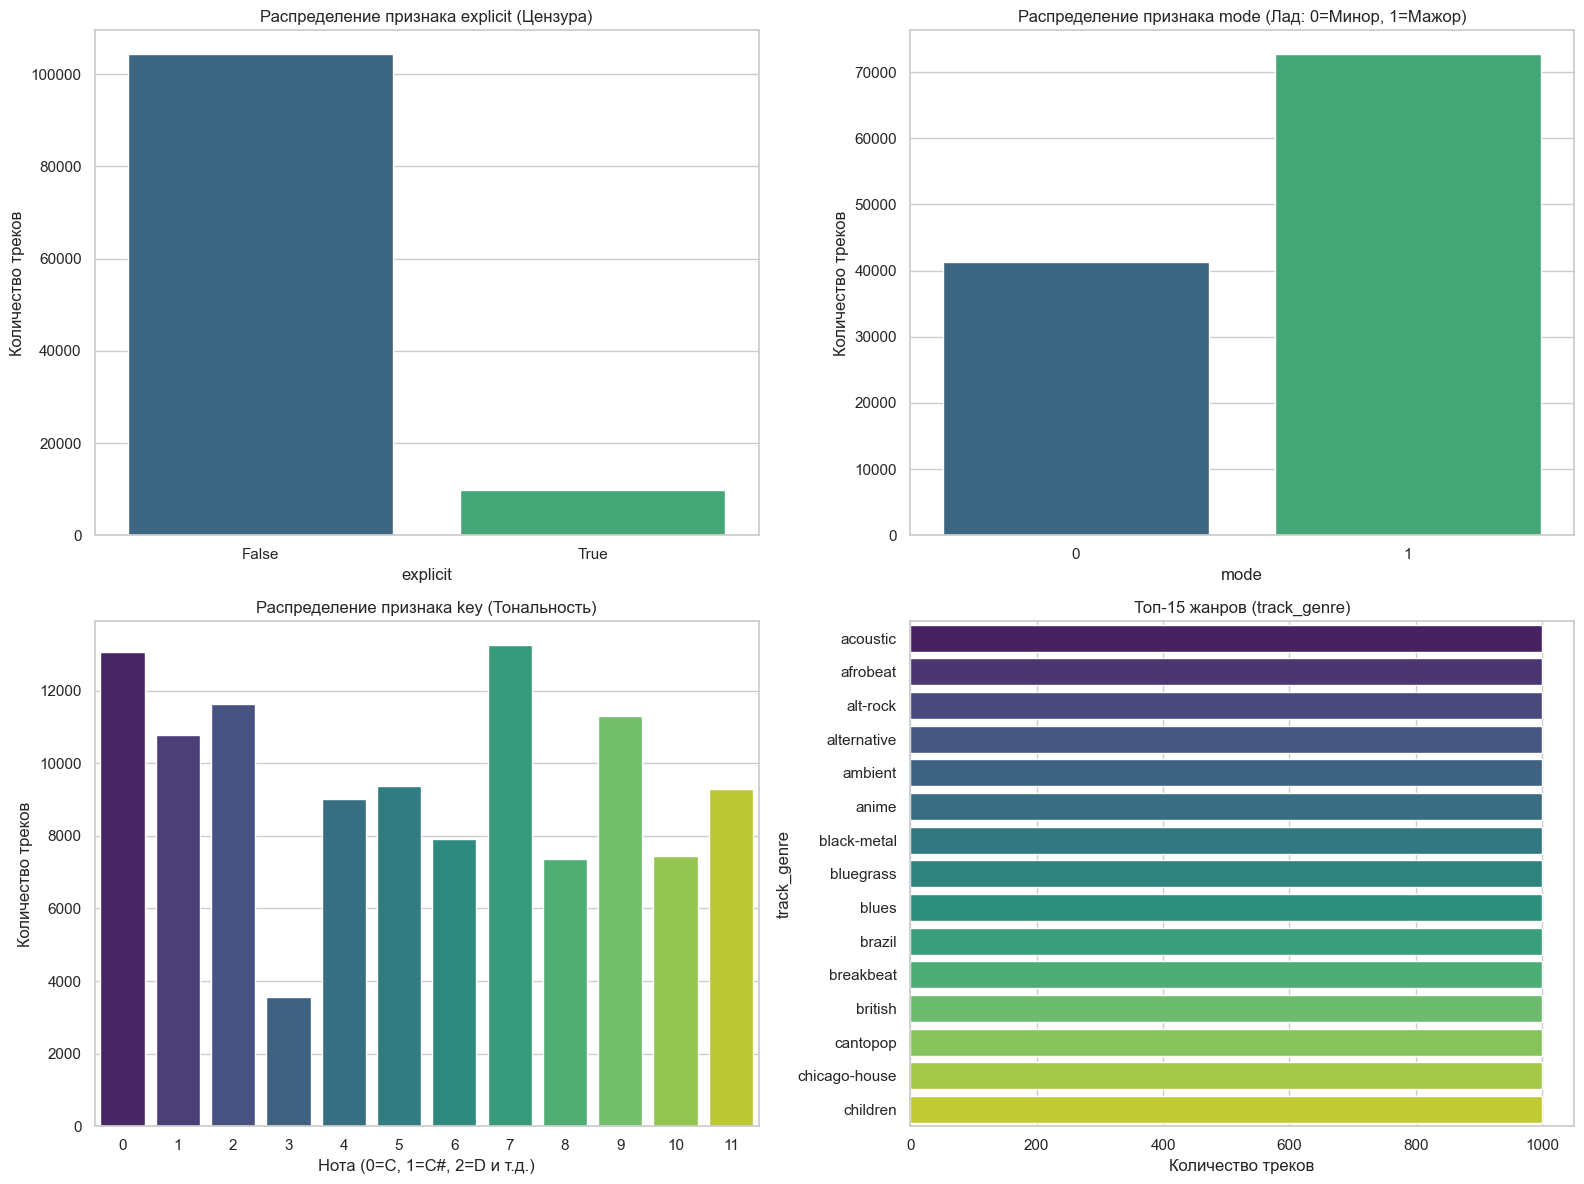

In [5]:
# Создаем холст для 4 графиков (2 строки, 2 столбца)
plt.figure(figsize=(16, 12))

# 1. Диаграмма для explicit (Цензура)
plt.subplot(2, 2, 1)
# countplot автоматически считает количество каждого класса и строит столбики
sns.countplot(data=df, x='explicit', palette='viridis')
plt.title('Распределение признака explicit (Цензура)')
plt.ylabel('Количество треков')

# 2. Диаграмма для mode (Лад: 0 - Минор, 1 - Мажор)
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='mode', palette='viridis')
plt.title('Распределение признака mode (Лад: 0=Минор, 1=Мажор)')
plt.ylabel('Количество треков')

# 3. Диаграмма для key (Тональность: 0-11)
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='key', palette='viridis')
plt.title('Распределение признака key (Тональность)')
plt.ylabel('Количество треков')
plt.xlabel('Нота (0=C, 1=C#, 2=D и т.д.)')

# 4. Диаграмма для track_genre (Топ-15 жанров)
plt.subplot(2, 2, 4)
# Считаем количество треков по жанрам, берем 15 самых частых и получаем их названия
top_genres = df['track_genre'].value_counts().head(15).index
# Строим график только для этих 15 жанров, располагаем их горизонтально (y=...) для читаемости
sns.countplot(data=df[df['track_genre'].isin(top_genres)], y='track_genre', order=top_genres, palette='viridis')
plt.title('Топ-15 жанров (track_genre)')
plt.xlabel('Количество треков')

# Убираем наложения
plt.tight_layout()
plt.show()

## Анализ категориальных признаков

* explicit. Наблюдается сильный дисбаланс. Подавляющее большинство треков в датасете не содержат ненормативной лексики.
* mode. Преобладает мажорная тональность. 
* key. Распределение относительно равномерное, но выделяются явные лидеры.

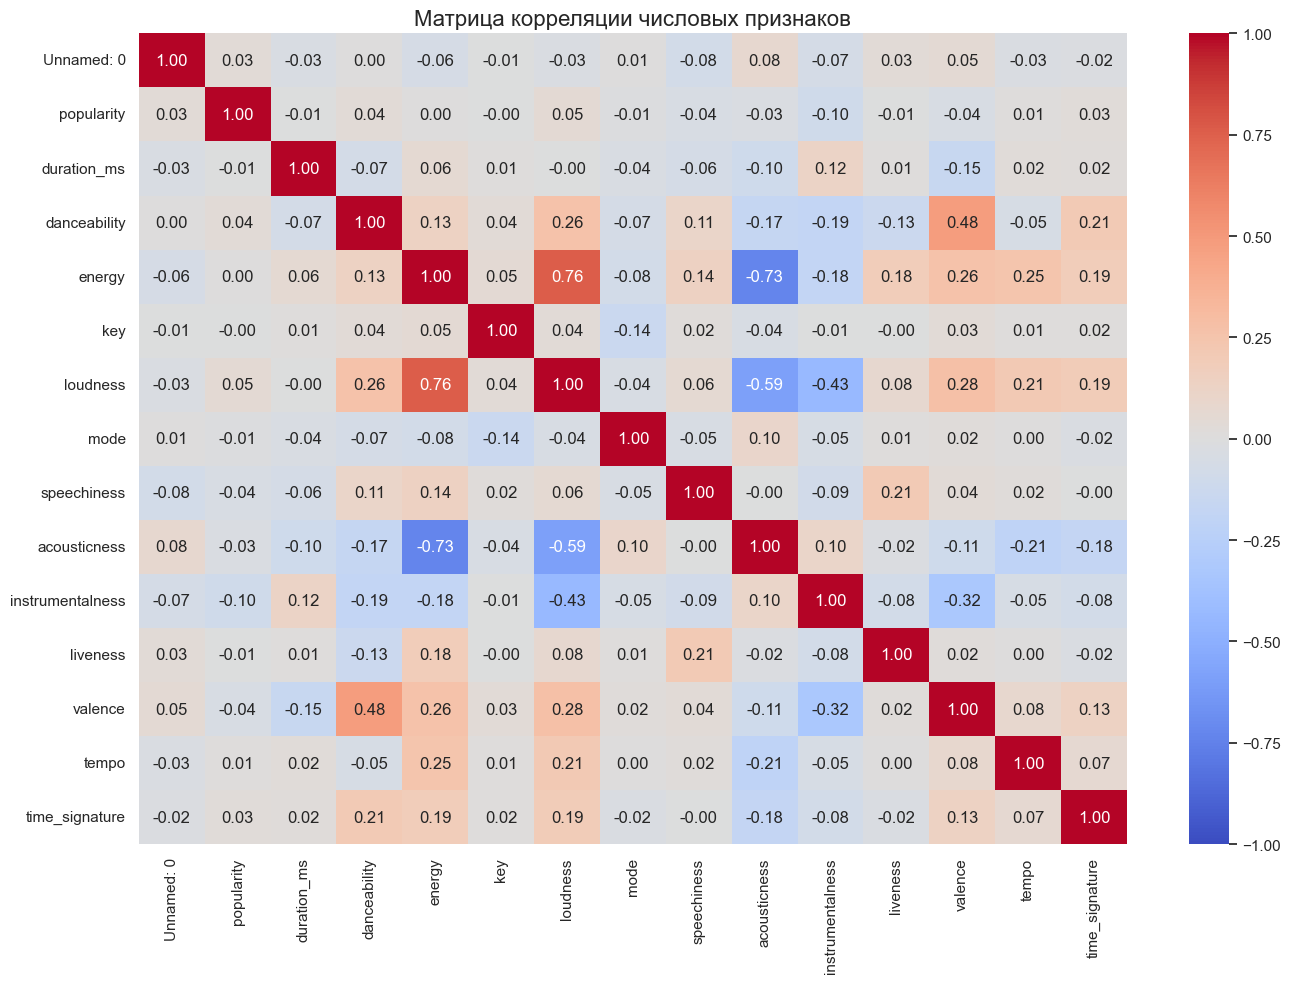

In [6]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# ычисляем матрицу корреляций
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title('Матрица корреляции числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

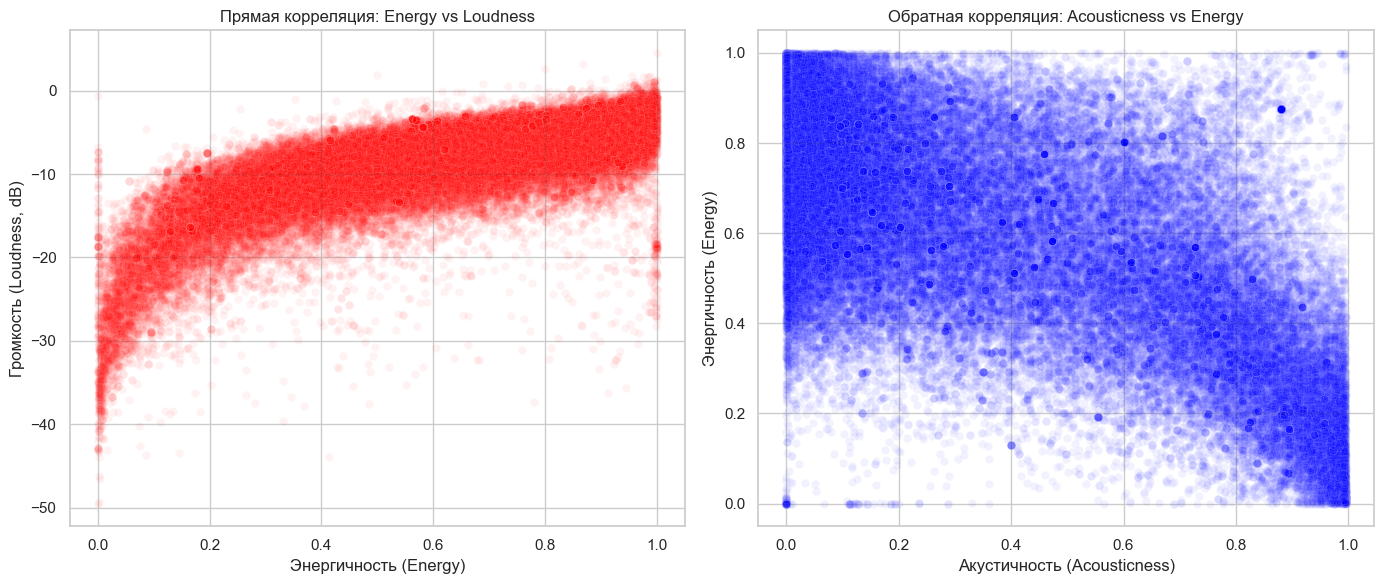

In [7]:
plt.figure(figsize=(14, 6))

# График 1: Прямая связь (Energy vs Loudness)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='energy', y='loudness', alpha=0.05, color='red')
plt.title('Прямая корреляция: Energy vs Loudness')
plt.xlabel('Энергичность (Energy)')
plt.ylabel('Громкость (Loudness, dB)')

# График 2: Обратная связь (Acousticness vs Energy)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='acousticness', y='energy', alpha=0.05, color='blue')
plt.title('Обратная корреляция: Acousticness vs Energy')
plt.xlabel('Акустичность (Acousticness)')
plt.ylabel('Энергичность (Energy)')

plt.tight_layout()
plt.show()

## Анализ взаимосвязей

* Пары с высокой положительной корреляцией:
*  energy и loudness - Самая сильная положительная связь в датасете. Диаграмма рассеяния показывает четкий восходящий тренд: чем выше значение energy (от 0 до 1), тем плотнее значения loudness группируются у верхней границы шкалы децибел ближе к 0. 
*   valence и danceabilit-  положительная связь. Более позитивные треки лучше подходят для танцев.

* Пары с высокой отрицательной корреляцией :
* energ  и acousticness - Самая сильная обратная связь. На диаграмме рассеяния видно, что треки с высокой акустичностью практически не имеют высокой энергичности, точки скапливаются в левом верхнем и правом нижнем углах.
*   loudness и acousticness - Также логичная обратная связь - акустические записи звучат тише.

* Связь с целевой переменной popularity
Матрица показывает, что ни один из аудио-признаков по отдельности не имеет сильной прямой линейной корреляции с популярностью. Это означает, что популярность — сложный, комплексный признак, и простой формулы по одному параметру не существует. 

## 3. Основные выводы на основе проведенного EDA

Исследовательский анализ данных позволил выявить ключевые характеристики и внутренние закономерности датасета.

1.  Распределения признаков: Большинство числовых аудиохарактеристик не являются нормально распределенными. Признаки, отражающие наличие какого-либо качества (например, acousticnes), сильно скошены вправо, что говорит о редкости этих качеств в общей массе треков. Признаки energy и danceability скошены влево, указывая на преобладание в датасете громкой музыки.

2.  Наличие выбросов: Для duration_ms и loudness, характерно значительное количество выбросов. Это говорит о наличии в данных очень длинных или очень тихих треков, которые могут негативно повлиять на обучение некоторых моделей.

3.  Взаимосвязи: Обнаружены сильные и логичные корреляции между внутренними аудио-признаками, однако ни один из признаков не показал сильной линейной корреляции с целевой переменной popularity. Это главный вывод: популярность является сложным, многофакторным свойством, и ее невозможно предсказать с помощью одного или двух простых параметров.


## 4. Описание выявленных закономерностей и аномалий

Описано выше в пунктах 1 и 2.


## 5. Рекомендации по дальнейшей подготовке данных к моделированию

На основе EDA можно дать следующие рекомендации перед построением ML-модели:

1.  Удаление явных аномалий (например, треков длиннее 15 минут) или использовать для масштабирования более устойчивые скейлеры.
2.  Поскольку простые признаки слабо коррелируют с популярностью, стоит попробовать создать более комплексные признаки. Например, danceability * energy.


## 6. Гипотезы для дальнейшего исследования

Главная гипотеза - можно выявить сложно свойство, задействующее несколько простых признаков, которое будет кореллировать с метрикой популярности.